# Week 1 Starter: Baseline PPO on Walker2D

**Starter Notebook -- Week 1**

This notebook is your starting point for the project.  
By the end of Week 1 you should complete the cells marked `TODO` and answer the reflection questions.

**Deliverables for this week:**
1. Environment runs without errors.
2. Baseline PPO training starts and TensorBoard log is visible.
3. You can describe what the observation vector means.
4. You understand what `ep_rew_mean` tells you.

---
> **Tip:** Read `Week1/guide.tex` (compile it or view the PDF) before running this notebook.

---
## Step 1: Verify your environment setup

In [ ]:
# Run this cell first.  It checks that all packages are installed.
import sys, importlib

required = ['pybullet', 'gymnasium', 'stable_baselines3', 'tensorboard', 'numpy', 'matplotlib']

all_ok = True
for pkg in required:
    try:
        importlib.import_module(pkg)
        print(f'  OK   {pkg}')
    except ImportError:
        print(f'  MISSING  {pkg}')
        all_ok = False

if not all_ok:
    print('\nPlease run:  pip install -r requirements.txt')
else:
    print('\nAll packages found.  Python:', sys.version.split()[0])

  OK   pybullet
  OK   gymnasium
  OK   stable_baselines3
  OK   tensorboard
  OK   numpy
  OK   matplotlib

All packages found.  Python: 3.12.3


In [ ]:
import os
print(os.getcwd())

/home/shloka-tomar/RL


---
## Step 2: Explore the Walker2D Environment

Before training anything, explore the environment manually.  
This is always a good first step: understand what states and actions look like.

In [1]:
import sys, os

# Make sure the project root is on the path so we can import env/
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from env import Walker2DEnv
import numpy as np

# Create the environment in headless mode (no GUI window)
env = Walker2DEnv(render_mode=None)

print('Observation space:', env.observation_space)
print('Action space:     ', env.action_space)
print()

# Reset and print the initial observation
obs, info = env.reset(seed=0)
print('Initial observation (22 values):')
print(np.round(obs, 4))

env.close()

Observation space: Box(-inf, inf, (22,), float32)
Action space:      Box(-1.0, 1.0, (6,), float32)

Initial observation (22 values):
[ 1.4 -0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.   0.   0. ]


pybullet build time: Mar  5 2026 22:05:45


In [8]:
# Let us see what happens when the agent takes random actions

env = Walker2DEnv(render_mode=None)
obs, _ = env.reset(seed=42)

episode_reward = 0.0
n_steps = 0

for _ in range(1000):
    action = env.action_space.sample()   # completely random action
    obs, reward, terminated, truncated, info = env.step(action)
    episode_reward += reward
    n_steps += 1
    if terminated or truncated:
        break

env.close()

print(f'Random policy:  {n_steps} steps,  total reward = {episode_reward:.2f}')
print()
print('This is the baseline we need to beat with PPO.')

Random policy:  1000 steps,  total reward = 1078.02

This is the baseline we need to beat with PPO.


### TODO 2.1 -- Understand the observation vector

Read `env/walker_env.py` (the `_get_obs` method) and `Week1/guide.tex` (Table 1).  
Fill in the table below:

| Index | Meaning | Unit |
|-------|---------|------|
| 0 | torso height | m |
| 1 | torso pitch | rad |
| 2-7 | joint angles | rad |
| 8-13 | joint velocities | m/s |
| 14 | forward velocity | m/s |
| 15 | lateral velocity | m/s |
| 16 | vertical velocity | m/s |
| 17 | pitch rate | rad/s |
| 18,19 | contacts (left and right) | binary |
| 20,21 | left and right thigh | rad |



---
## Step 3: Run Baseline PPO Training

Here you will train a PPO agent with the default reward function for 200,000 steps.  
This is a short run just to verify everything works and see the training curve.  
The proper 1M-step training run happens in Week 4.

In [3]:
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import SubprocVecEnv, VecNormalize
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import EvalCallback

TOTAL_STEPS = 200_000
N_ENVS      = 4
LOG_DIR     = '../runs/week1_baseline'
os.makedirs(LOG_DIR, exist_ok=True)

# Create vectorised environments
# We use a lambda so each env gets a different random seed
def make_env(seed=0):
    def _init():
        e = Walker2DEnv(render_mode=None)
        e.reset(seed=seed)
        return e
    return _init

train_env = make_vec_env(make_env(seed=0), n_envs=N_ENVS)
train_env = VecNormalize(train_env, norm_obs=True, norm_reward=True, clip_obs=10.0)

print('Training environment ready.')
print('Observation space after VecNormalize:', train_env.observation_space)

Training environment ready.
Observation space after VecNormalize: Box(-inf, inf, (22,), float32)


In [4]:
# Create PPO model -- BASELINE configuration (do not change for Week 1)
model = PPO(
    policy          = 'MlpPolicy',
    env             = train_env,
    learning_rate   = 3e-4,
    n_steps         = 2048,
    batch_size      = 64,
    n_epochs        = 10,
    gamma           = 0.99,
    gae_lambda      = 0.95,
    clip_range      = 0.2,
    ent_coef        = 0.0,
    policy_kwargs   = dict(net_arch=[256, 256]),
    verbose         = 1,
    tensorboard_log = LOG_DIR,
)

print('Model created.')

Using cpu device
Model created.


In [5]:
# EvalCallback: test the agent on a fresh environment every 20k steps
eval_env = make_vec_env(make_env(seed=99), n_envs=1)
eval_env = VecNormalize(eval_env, training=False,
                        norm_obs=True, norm_reward=False, clip_obs=10.0)

# Keep eval normaliser statistics in sync with training normaliser
eval_env.obs_rms = train_env.obs_rms

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path = LOG_DIR,
    log_path             = LOG_DIR,
    eval_freq            = 20_000,
    n_eval_episodes      = 10,
    deterministic        = True,
    verbose              = 1,
)

print(f'Training for {TOTAL_STEPS:,} steps...')
print('To watch progress in TensorBoard, open a terminal and run:')
print(f'  tensorboard --logdir {os.path.abspath(LOG_DIR)}')
print()

model.learn(
    total_timesteps     = TOTAL_STEPS,
    callback            = eval_callback,
    tb_log_name         = 'baseline',
    reset_num_timesteps = True,
)

# Save final model + normalisation stats
model.save(os.path.join(LOG_DIR, 'final_model'))
train_env.save(os.path.join(LOG_DIR, 'vecnorm.pkl'))

print('Training complete.')

Training for 200,000 steps...
To watch progress in TensorBoard, open a terminal and run:
  tensorboard --logdir /home/shloka-tomar/RL/ppo-walker-rl/runs/week1_baseline

Logging to ../runs/week1_baseline/baseline_2
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | 1.08e+03 |
| time/              |          |
|    fps             | 1041     |
|    iterations      | 1        |
|    time_elapsed    | 7        |
|    total_timesteps | 8192     |
---------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 1e+03      |
|    ep_rew_mean          | 1.08e+03   |
| time/                   |            |
|    fps                  | 830        |
|    iterations           | 2          |
|    time_elapsed         | 19         |
|    total_timesteps      | 16384      |
| train/                  |            |
|    approx_kl            | 0.008991

---
## Step 4: Plot the Training Curve

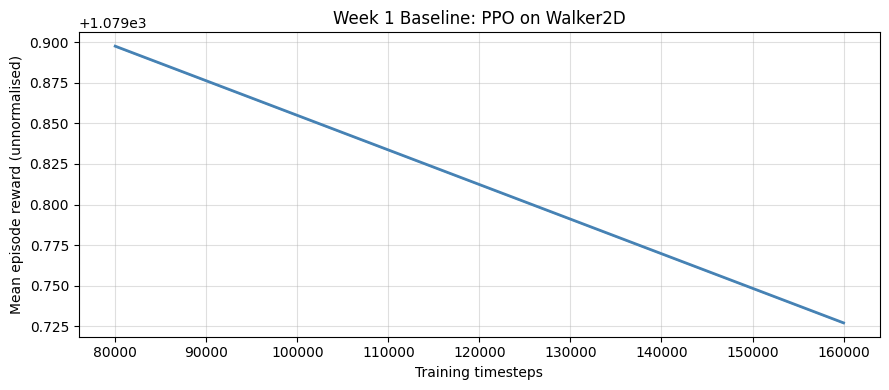

Plot saved to ../runs/week1_baseline


In [6]:
import matplotlib.pyplot as plt

eval_data = np.load(os.path.join(LOG_DIR, 'evaluations.npz'))
ts   = eval_data['timesteps']
rews = eval_data['results'].mean(axis=1)
stds = eval_data['results'].std(axis=1)

plt.figure(figsize=(9, 4))
plt.fill_between(ts, rews - stds, rews + stds, alpha=0.3, color='steelblue')
plt.plot(ts, rews, color='steelblue', linewidth=2)
plt.xlabel('Training timesteps')
plt.ylabel('Mean episode reward (unnormalised)')
plt.title('Week 1 Baseline: PPO on Walker2D')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, 'training_curve.png'), dpi=120)
plt.show()
print('Plot saved to', LOG_DIR)

---
## Step 5: Quick Evaluation

In [7]:
# Load the best model that was saved during training
from stable_baselines3.common.evaluation import evaluate_policy

best_model = PPO.load(os.path.join(LOG_DIR, 'best_model'))

# Create a non-normalised env for raw reward evaluation
test_env = Walker2DEnv(render_mode=None)

# NOTE: the model was trained on normalised observations.
# For a proper evaluation you should use VecNormalize with training=False.
# This quick test uses raw obs for simplicity; for accurate numbers use evaluate.py.

rewards_list = []
steps_list   = []

for ep in range(5):
    obs, _ = test_env.reset()
    total_r = 0.0
    n_steps = 0
    while True:
        action, _ = best_model.predict(obs, deterministic=True)
        obs, r, terminated, truncated, _ = test_env.step(action)
        total_r += r
        n_steps += 1
        if terminated or truncated:
            break
    rewards_list.append(total_r)
    steps_list.append(n_steps)
    print(f'  Episode {ep+1}: {n_steps} steps, reward = {total_r:.2f}')

test_env.close()
print(f'\nMean: {np.mean(rewards_list):.2f} reward,  {np.mean(steps_list):.0f} steps')

  Episode 1: 1000 steps, reward = 1079.77
  Episode 2: 1000 steps, reward = 1079.77
  Episode 3: 1000 steps, reward = 1079.77
  Episode 4: 1000 steps, reward = 1079.77
  Episode 5: 1000 steps, reward = 1079.77

Mean: 1079.77 reward,  1000 steps


---
## Reflection Questions (answer before Week 2)

Write your answers in the markdown cell below each question.

---
**Q1.** What does `VecNormalize` do and why is it important for the Walker2D environment?

It normalizes observations and rewards during training. It's particularly important in the Walker2D environment because our observation vectors have things like angles, velocities, forces, which have really different magnitudes. Large values would dominate gradients and the learning would become unstable. Rewards can also vary a lot while training, and could similarly cause the gradients to explode.
Also, advantages depend on the reward scale. 

**Q2.** Look at the `ep_rew_mean` curve in TensorBoard.  
Is it increasing? What would a flat curve at a low value suggest?

The ep_rew_mean curve represents the average total reward per episode during training. 
Each episode produces a sum of rewards, and then TensorBoard logs the mean of those rewards across recent episodes. 
The curve is increasing. This means the model is getting better over time by learning. 
A flat curve at a low value would mean the model is stuck at a low reward and is unable to learn and improve its policies.

**Q3.** How many steps does a random agent last compared to the trained agent?  
What does this tell you about what PPO has learned?

In my case both the random agent and best agent worked the same? - Not sure why, will update after figuring it out.

**Q4.** The default reward function includes an energy penalty term.  
Why might penalising high action magnitudes lead to a better walking gait?

High action magnitudes often correspond to 'risky' actions like taking a step that's too large or too fast. Penalizing them would lead to a more smooth and energy-efficient gait and further help prevent falling.
Also, without a penalty, the agent may exploit this by thrashing its legs aggressively to gain reward or learn weird unnatural movements.

---
## What to bring to the Week 1 check-in

- [ ] This notebook with all cells executed and reflection questions answered.
- [ ] A screenshot or exported image of the TensorBoard `ep_rew_mean` curve.
- [ ] Be ready to explain: what are observations, actions, and rewards *in this specific environment*?
- [ ] Be ready to answer: what does the training curve look like and what does it mean?